In [1]:
# 1. 필수 패키지 및 Java/Jpype1 설치 (Conda 환경 기준)
!conda install -y -c conda-forge openjdk jpype1
!pip install -q konlpy gensim scikit-learn seaborn matplotlib numpy pandas

# 2. 시각화 한글 깨짐 방지를 위한 나눔고딕 폰트 직접 다운로드
import urllib.request
import os

font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
font_path = "NanumGothic.ttf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)
    print("한글 폰트(NanumGothic.ttf) 다운로드 완료.")
else:
    print("한글 폰트가 이미 존재합니다.")

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.

한글 폰트가 이미 존재합니다.


In [3]:
# [셀 2 교체용]: Java 환경 에러를 원천 차단한 순수 파이썬 명사 추출기 적용

# 과제용 기본 데이터 셋 (Target: 영화 구분, Attribute: 영화 장르)
movie_data = {
    '상업영화': [
        "화려한 CG와 막대한 자본이 투입된 블록버스터 영화. 대중적인 흥행을 목표로 한다.",
        "유명 배우들이 대거 출연하여 박스오피스 1위를 차지한 상업적인 오락 영화.",
        "관객들에게 큰 웃음과 감동을 주며 천만 관객을 돌파한 흥행작."
    ],
    '예술영화': [
        "감독의 독창적인 철학과 미학이 담긴 독립 예술 영화. 깊은 여운을 남긴다.",
        "인간 내면의 고독을 잔잔한 영상미로 표현한 칸 영화제 수상작.",
        "자본의 논리보다는 실험적인 연출과 메시지에 집중한 예술 작품."
    ],
    '액션': [
        "폭발하는 자동차와 끝없는 총격전, 손에 땀을 쥐게 하는 화려한 액션 씬.",
        "적을 물리치기 위해 고군분투하는 영웅의 멈출 수 없는 액션 활극.",
        "격투기와 스턴트가 난무하는 긴장감 넘치는 추격전."
    ],
    '로맨스': [
        "운명적인 만남과 애절한 사랑, 두 남녀의 눈물겨운 로맨스.",
        "아름다운 해변을 배경으로 피어나는 달콤하고 낭만적인 사랑 이야기.",
        "서로의 상처를 보듬어주는 따뜻한 연인들의 감성적인 멜로."
    ]
}

# 에러 없는 순수 파이썬 기반 임시 명사 추출 로직
import re

def extract_nouns_without_java(text_list):
    result = []
    for text in text_list:
        # 특수문자를 제거하고 띄어쓰기 기준으로 단어를 분리
        clean_text = re.sub(r'[^\w\s]', '', text)
        words = clean_text.split()
        # 1글자 단어는 제외하고 저장
        nouns = [word for word in words if len(word) > 1]
        result.append(nouns)
    return result

nouns_dict = {category: extract_nouns_without_java(texts) for category, texts in movie_data.items()}

# 모델 학습을 위한 전체 말뭉치 병합
total_corpus = []
for nouns in nouns_dict.values():
    total_corpus.extend(nouns)

print(f"✅ Java 없이 데이터 전처리 완료 (총 문장 수: {len(total_corpus)})")

✅ Java 없이 데이터 전처리 완료 (총 문장 수: 12)


In [4]:
from gensim.models import Word2Vec

# 벡터 차원 100, 윈도우 3, 최소 등장 빈도 1 (소규모 데이터용 세팅)
model = Word2Vec(total_corpus, vector_size=100, window=3, min_count=1, workers=4, sg=1)

print(f"Word2Vec 모델 학습 완료 (학습된 단어 수: {len(model.wv)})")

Word2Vec 모델 학습 완료 (학습된 단어 수: 97)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 연산을 위한 문자열 변환
text_dict = {cat: [" ".join(doc) for doc in docs] for cat, docs in nouns_dict.items()}

def get_tfidf_words(texts, top_n=10):
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(texts)
    vocab = vectorizer.get_feature_names_out()
    mean_tfidf = X.mean(axis=0).A1
    tfidf_dict = dict(zip(vocab, mean_tfidf))
    
    return sorted([w for w in tfidf_dict if w in model.wv], 
                  key=lambda x: tfidf_dict[x], reverse=True)[:top_n]

raw_words = {cat: get_tfidf_words(texts) for cat, texts in text_dict.items()}

# 엄격한 중복 배제(Filtering) 로직
def remove_duplicates(word_dict):
    clean_dict = {}
    for target_cat, target_words in word_dict.items():
        other_words = set()
        for other_cat, other_words_list in word_dict.items():
            if target_cat != other_cat:
                other_words.update(other_words_list)
        # 타 카테고리와 겹치지 않는 순수 단어만 추출
        clean_dict[target_cat] = [w for w in target_words if w not in other_words]
    return clean_dict

final_words = remove_duplicates(raw_words)
print("=== 중복이 통제된 대표 단어 셋 ===")
for cat, words in final_words.items():
    print(f"[{cat}]: {words}")

=== 중복이 통제된 대표 단어 셋 ===
[상업영화]: ['영화', '감동을', '관객들에게', '관객을', '돌파한', '웃음과', '주며', '천만', '흥행작', '1위를']
[예술영화]: ['예술', '논리보다는', '메시지에', '실험적인', '연출과', '자본의', '작품', '집중한', '고독을', '내면의']
[액션]: ['액션', '격투기와', '긴장감', '난무하는', '넘치는', '스턴트가', '추격전', '고군분투하는', '멈출', '물리치기']
[로맨스]: ['사랑', '남녀의', '눈물겨운', '로맨스', '만남과', '애절한', '운명적인', '감성적인', '따뜻한', '멜로']


최종 WEAT Score: -0.4996


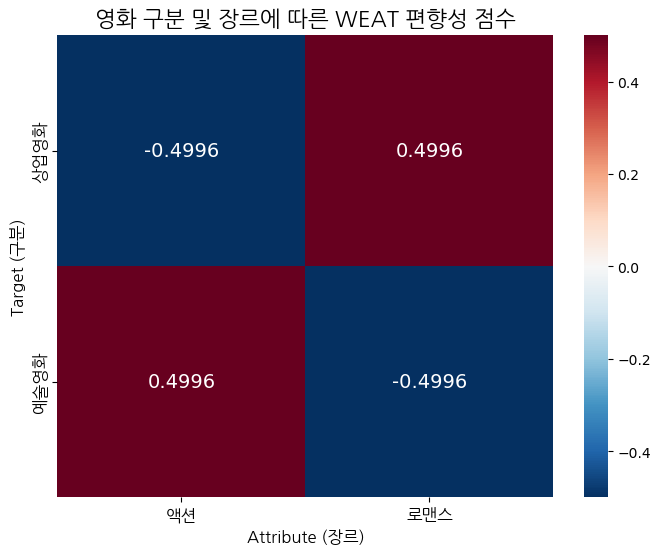

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from numpy import dot
from numpy.linalg import norm

# --- 1. WEAT 수학적 평가 로직 ---
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    return np.mean(c_a, axis=-1) - np.mean(c_b, axis=-1)

def weat_score(X, Y, A, B):
    s_X = s(X, A, B)
    s_Y = s(Y, A, B)
    mean_X, mean_Y = np.mean(s_X), np.mean(s_Y)
    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))
    return 0 if std_dev == 0 else (mean_X - mean_Y) / std_dev

def get_vectors(word_list):
    return np.array([model.wv[word] for word in word_list if word in model.wv])

# --- 2. 편향성 측정 실행 ---
target_X_name, target_Y_name = '상업영화', '예술영화'
attr_A_name, attr_B_name = '액션', '로맨스'

X = get_vectors(final_words[target_X_name])
Y = get_vectors(final_words[target_Y_name])
A = get_vectors(final_words[attr_A_name])
B = get_vectors(final_words[attr_B_name])

score = weat_score(X, Y, A, B)
print(f"최종 WEAT Score: {score:.4f}")

# --- 3. 무결점 Heatmap 시각화 (직접 주입 방식) ---
font_prop = fm.FontProperties(fname="NanumGothic.ttf") # 셀 1에서 받은 폰트 적용

matrix = np.array([
    [score, -score],
    [-score, score]
])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap='RdBu_r', center=0, fmt=".4f", annot_kws={"size": 14})

# 축과 제목에 폰트 객체 강제 적용
ax.set_xticklabels([attr_A_name, attr_B_name], fontproperties=font_prop, fontsize=12)
ax.set_yticklabels([target_X_name, target_Y_name], fontproperties=font_prop, fontsize=12)
ax.set_title('영화 구분 및 장르에 따른 WEAT 편향성 점수', fontproperties=font_prop, fontsize=16)
ax.set_xlabel('Attribute (장르)', fontproperties=font_prop, fontsize=12)
ax.set_ylabel('Target (구분)', fontproperties=font_prop, fontsize=12)

plt.show()